# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import json
import mthree
from datetime import datetime

from qiskit import *
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (NoiseModel, QuantumError, ReadoutError, pauli_error, depolarizing_error, thermal_relaxation_error)
from qiskit_ibm_runtime import QiskitRuntimeService, Session, SamplerV2, Options, SamplerOptions

In [ ]:
token = '' # Put in your IBM token
QiskitRuntimeService.save_account(channel="ibm_quantum", token=token, overwrite= True)

# Functions for writing CI-Regime Circuits

In [2]:
def swap(qc, qubit1, qubit2):
    qc.cx(qubit1, qubit2)
    qc.cx(qubit2, qubit1)
    qc.cx(qubit1, qubit2)

def rxx(qc, phi, qubit1, qubit2):
    qc.h([qubit1, qubit2])
    qc.cx(qubit1, qubit2)
    qc.rz(phi, qubit2)
    qc.cx(qubit1, qubit2)
    qc.h([qubit1, qubit2])

def give_base_circuit(qc, phi):
    qc.h([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    qc.cz(0, 1)
    qc.cz(2, 3)
    qc.cz(4, 5)
    qc.cz(6, 7)
    qc.cz(8, 9)
    qc.cz(1, 2)
    qc.cz(3, 4)
    qc.cz(5, 6)
    qc.cz(7, 8)
    qc.cz(9, 10)

    swap(qc, 2, 3)
    swap(qc, 7, 8)
    rxx(qc, phi, 3, 4)
    rxx(qc, phi, 6, 7)
    swap(qc, 5, 6)
    rxx(qc, phi, 4, 5)

    qc.rx(phi, 3)
    qc.rx(phi, 7)

In [3]:
def generate_tworot_circuit(beta, phi, meas_last_x):
    """
    Generates one circuit corresponding to doing two close rotations
    A cluster state is prepared, then a rotation is conducted on the third/fifth sites. A state tomography measurement
    (either X or Y) is conducted on the last (11th) qubit.

    Inputs: beta - Rotation angle
            phi - R_{ZkZk+2}(phi) rotation applied across 2-local connections
            meas_last_x - Whether the ninth qubit is measured in the Y or X basis
    Outputs: The circuit
    """
    qr = QuantumRegister(11)
    cr = ClassicalRegister(11)
    qc = QuantumCircuit(qr, cr)

    give_base_circuit(qc, phi)

    qc.rz(beta/2, 3)
    qc.rz(beta/2, 4)

    if meas_last_x == 0:
        qc.sdg(10)  

    qc.h(qr)

    qc.measure(0, 0)
    qc.measure(1, 1)
    qc.measure(3, 2)
    qc.measure(2, 3)
    qc.measure(4, 4)
    qc.measure(6, 5)
    qc.measure(5, 6)
    qc.measure(8, 7)
    qc.measure(7, 8)
    qc.measure(9, 9)
    qc.measure(10, 10)
    
    return qc

def generate_tworot_circuit_spaced(beta, phi, meas_last_x):
    """
    Generates one circuit corresponding to doing two spaced rotations
    A cluster state is prepared, then a rotation is conducted on the third/ninth sites. A state tomography measurement
    (either X or Y) is conducted on the last (11th) qubit.

    Inputs: beta - Rotation angle
            phi - R_{ZkZk+2}(phi) rotation applied across 2-local connections
            meas_last_x - Whether the ninth qubit is measured in the Y or X basis
    Outputs: The circuit
    """
    qr = QuantumRegister(11)
    cr = ClassicalRegister(11)
    qc = QuantumCircuit(qr, cr)

    give_base_circuit(qc, phi)

    qc.rz(beta/2, 3)
    qc.rz(beta/2, 7)

    if meas_last_x == 0:
        qc.sdg(10)  

    qc.h(qr)
    
    qc.measure(0, 0)
    qc.measure(1, 1)
    qc.measure(3, 2)
    qc.measure(2, 3)
    qc.measure(4, 4)
    qc.measure(6, 5)
    qc.measure(5, 6)
    qc.measure(8, 7)
    qc.measure(7, 8)
    qc.measure(9, 9)
    qc.measure(10, 10)
    
    return qc

def generate_fourrot_circuit(beta, phi, meas_last_x):
    qr = QuantumRegister(11)
    cr = ClassicalRegister(11)
    qc = QuantumCircuit(qr, cr)

    give_base_circuit(qc, phi)

    qc.rz(beta/4, 3)
    qc.rz(beta/4, 4)
    qc.rz(beta/4, 5)
    qc.rz(beta/4, 7)

    if meas_last_x == 0:
        qc.sdg(10)  

    qc.h(qr)

    qc.measure(0, 0)
    qc.measure(1, 1)
    qc.measure(3, 2)
    qc.measure(2, 3)
    qc.measure(4, 4)
    qc.measure(6, 5)
    qc.measure(5, 6)
    qc.measure(8, 7)
    qc.measure(7, 8)
    qc.measure(9, 9)
    qc.measure(10, 10)
    
    return qc

In [4]:
def generate_counterintuitive_circuits(beta_ar, phi_ar, repeats=1):
    """
    Generates n circuits (one for each rotation angle)
    Inputs: beta_ar - array of rotation angles
            ab_ar - array of variational ansatz states
    Outputs: List of 2 * len(beta_ar) circuits
    """ 
    qc_list = []
    for phi in phi_ar:
        for num_rots in [2, 22, 4]:
            for beta in beta_ar:
                for meas_last_x in range(2):
                        for _ in range(repeats):
                            if num_rots == 2:
                                qc_list.append(generate_tworot_circuit(beta, phi, meas_last_x))
                            elif num_rots == 22:
                                qc_list.append(generate_tworot_circuit_spaced(beta, phi, meas_last_x))
                            else:
                                qc_list.append(generate_fourrot_circuit(beta, phi, meas_last_x))
    return qc_list

# Running the CI-regime circuits

In [5]:
best_qubits = [64, 63, 62, 72, 81, 80, 79, 91, 98, 97, 96]
shots_num = 10000
shots_per_randomization = 10000
beta_ar = np.linspace(0, np.pi/2, 12)
phi_ar = [np.pi/4]
num_repeats = 20

In [6]:
service = QiskitRuntimeService()
backend = service.backend("ibm_quebec")
mit = mthree.M3Mitigation(backend)

RequestsApiError: 'HTTPSConnectionPool(host=\'auth.quantum-computing.ibm.com\', port=443): Max retries exceeded with url: /api/version (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x157de0810>: Failed to resolve \'auth.quantum-computing.ibm.com\' ([Errno 8] nodename nor servname provided, or not known)"))'

In [ ]:
mit.cals_from_system(best_qubits) # if mitigating current state of the device
mit.cals_to_file('CI_cals_date.json')

In [85]:
t = datetime.now()
properties = backend.properties(datetime=t)  # Obtain IBMQ backend calibration data at given time
prop_dict = properties.to_dict()
with open("CI_IBM_calibrations_sep7_1.json", "w") as fp:
    json.dump(prop_dict, fp, indent=2, default=str)  # Save calibration as JSON

In [ ]:
with Session(backend=backend, max_time="6h") as session:
    options = SamplerOptions()
    options.dynamical_decoupling.enable = True
    options.dynamical_decoupling.sequence_type = "XX"
    options.twirling.enable_gates = True
    options.twirling.enable_measure = True
    options.twirling.shots_per_randomization = shots_per_randomization

    sampler = SamplerV2(mode=session, options=options)
    print(session.details())
    print(session.status())

    for i in range(num_repeats):
        qc_list_CI = transpile(generate_counterintuitive_circuits(beta_ar, phi_ar, 4), backend=backend, initial_layout=best_qubits)
        job_exp_CI = sampler.run(qc_list_CI, shots=shots_num)
        print(session.status())

In [50]:
# If directly getting counts from result
# result = job_exp_CI.result()
# counts_list = []
# for res in result:
#     for item in res.data.items():
#         counts_list.append(item[1].get_counts())

In [74]:
mit_counts_list = []
best_qubits_permuted = 11 * [0]
best_qubits_permuted[0] = best_qubits[0]
best_qubits_permuted[1] = best_qubits[1]
best_qubits_permuted[2] = best_qubits[3]
best_qubits_permuted[3] = best_qubits[2]
best_qubits_permuted[4] = best_qubits[4]
best_qubits_permuted[5] = best_qubits[6]
best_qubits_permuted[6] = best_qubits[5]
best_qubits_permuted[7] = best_qubits[8]
best_qubits_permuted[8] = best_qubits[7]
best_qubits_permuted[9] = best_qubits[9]
best_qubits_permuted[10] = best_qubits[10]

for raw_counts in counts_list:
    quasi_dist = mit.apply_correction(raw_counts, best_qubits_permuted)
    mit_counts = convert_to_counts_2(quasi_dist, shots_num)
    mit_counts_list.append(mit_counts)

In [79]:
purity_ar = post_process_results(mit_counts_list, beta_ar, phi_ar)

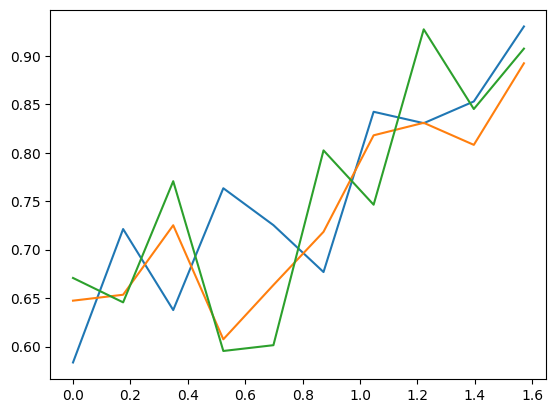

In [80]:
plt.plot(beta_ar, purity_ar[0:10])
plt.plot(beta_ar, purity_ar[10:20])
plt.plot(beta_ar, purity_ar[20:30])

# Post-processing Data

In [7]:
job_names_1 = ["cve0m1gw5350008x1qcg", "cve0m4rw5350008x1qe0", "cve0m7rvawwg0089550g", "cve0mas8w2g0008ect40", "cve0mds8w2g0008ect4g", "cve0mh28w2g0008ect5g", "cve0mm2w5350008x1qm0", "cve0mqap7drg008kwcz0", "cve0mtk8w2g0008ect6g", "cve0mxvw5350008x1qn0", "cve0n14z17rg008d6hgg", "cve0n4mp7drg008kwd1g", "cve0n7m8w2g0008ect7g", "cve0naxkmd100082d9fg", "cve0ne5w5350008x1qpg", "cve0nh6w5350008x1qq0", "cve0nkyp7drg008kwd30", "cve0nq68w2g0008ect80", "cve0nszw5350008x1qqg", "cve0nwzkmd100082d9gg"]

job_names_2 = ["cve4mzbz17rg008d6vn0", "cve4n248w2g0008ed590", "cve4n4ww5350008x21d0", "cve4n7cw5350008x21dg", "cve4nanw5350008x21e0", "cve4nddp7drg008kwr50", "cve4ng6z17rg008d6vpg", "cve4njyz17rg008d6vq0", "cve4nne8w2g0008ed5ag", "cve4nrfvawwg00895gsg", "cve4nv78w2g0008ed5c0", "cve4nxzvawwg00895gt0", "cve4p0gp7drg008kwr5g", "cve4p3gkmd100082dmbg", "cve4p60w5350008x21fg", "cve4p91vawwg00895gvg", "cve4pbskmd100082dmcg", "cve4peh8w2g0008ed5d0", "cve4phj8w2g0008ed5dg", "cve4pmakmd100082dmd0"]

job_names_3 = ["cve8syzvawwg00895spg", "cve8t208w2g0008ede1g", "cve8t4rw5350008x29v0", "cve8t7g8w2g0008ede2g", "cve8tahw5350008x29w0", "cve8tdhw5350008x29wg", "cve8tgjp7drg008kx18g", "cve8tkj8w2g0008ede40", "cve8tpjw5350008x29xg", "cve8tskw5350008x29y0", "cve8twkvawwg00895srg", "cve8tzkw5350008x29yg", "cve8v2mkmd100082dx20", "cve8v5m8w2g0008ede70", "cve8v8n8w2g0008ede7g", "cve8vbnp7drg008kx1bg", "cve8venz17rg008d74j0", "cve8vhpw5350008x2a0g", "cve8vn6vawwg00895ssg", "cve8vrfw5350008x2a1g"]

In [8]:
# Getting counts data from job names

# for job_name in job_names_1:
#     job = service.job(job_name)
#     result = job.result()
#     counts_list = []
#     for i in range(len(result)):
#         res = result[i]
#         for item in res.data.items():
#             counts_list.append(item[1].get_counts())
#     with open("CI_IBM_" + job_name + "_sep7_1.json", "w") as fp:
#         json.dump(counts_list, fp, indent=2, default=str)

In [9]:
best_qubits_permuted = 11 * [0]
best_qubits_permuted[0] = best_qubits[0]
best_qubits_permuted[1] = best_qubits[1]
best_qubits_permuted[2] = best_qubits[3]
best_qubits_permuted[3] = best_qubits[2]
best_qubits_permuted[4] = best_qubits[4]
best_qubits_permuted[5] = best_qubits[6]
best_qubits_permuted[6] = best_qubits[5]
best_qubits_permuted[7] = best_qubits[8]
best_qubits_permuted[8] = best_qubits[7]
best_qubits_permuted[9] = best_qubits[9]
best_qubits_permuted[10] = best_qubits[10]

def convert_to_counts_2(quasi_dist_dict, shots):
    count_dict = {}
    for key, val in quasi_dist_dict.items():
        count_dict[key] = val * shots
    return count_dict

In [14]:
# raw_counts_1 = []
# raw_counts_2 = []
# raw_counts_3 = []
# mit_counts_1 = []
# mit_counts_2 = []
# mit_counts_3 = []
mit_counts_all = []

# raw_counts = [raw_counts_1, raw_counts_2, raw_counts_3]
# mit_counts = [mit_counts_1, mit_counts_2, mit_counts_3]
job_names = [job_names_1, job_names_2, job_names_3]
mit_files = ["CI_cals_sep7_1.json", "CI_cals_sep7_2.json", "CI_cals_sep7_3.json"]
mit = mthree.M3Mitigation()
for i in range(3):
    # raw_counts_i = raw_counts[i]
    # mit_counts_i = mit_counts[i]
    job_names_i = job_names[i]
    mit.cals_from_file(mit_files[i])
    for job_name in job_names_i:
        f = open("CI_IBM_" + job_name + "_sep7_" + str(i+1) + ".json") 
        raw_counts_exp_list = json.load(f)
        for j in range(len(raw_counts_exp_list)):
            quasi_dist = mit.apply_correction(raw_counts_exp_list[j], best_qubits_permuted)
            mit_counts = convert_to_counts_2(quasi_dist, shots_num)
            mit_counts_all.append(mit_counts)
            # raw_counts_i.append(raw_counts_exp)
            # mit_counts_i.append(mit_counts)

In [15]:
def convert_bin(s):
    if s == 0:
        return 1
    else:
        return -1

def tworot_expectation(counts, meas_last_x):
    states = counts.keys()
    exp_val_correct = 0
    total_counts_correct = 0
    for state in states:
        count = counts.get(state)
        s1 = convert_bin(int(state[10]))
        # s2 = convert_bin(int(state[9]))
        s3 = convert_bin(int(state[8]))
        s4 = convert_bin(int(state[7]))
        s5 = convert_bin(int(state[6]))
        s6 = convert_bin(int(state[5]))
        s7 = convert_bin(int(state[4]))
        s8 = convert_bin(int(state[3]))
        s9 = convert_bin(int(state[2]))
        s10 = convert_bin(int(state[1]))
        s11 = convert_bin(int(state[0]))

        if meas_last_x == 1:
                s6 = 1
                s8 = 1
                s10 = 1
        outcome = s1 * s3 * s5 * s7 * s9 * s11 * s6 * s8 * s10
        if s4 == 1:
            exp_val_correct += outcome * count
            total_counts_correct += count
        
    return exp_val_correct/total_counts_correct

def tworot_expectation_spaced(counts, meas_last_x):
    states = counts.keys()
    exp_val_correct = 0
    total_counts_correct = 0
    for state in states:
        count = counts.get(state)
        s1 = convert_bin(int(state[10]))
        # s2 = convert_bin(int(state[9]))
        s3 = convert_bin(int(state[8]))
        s4 = convert_bin(int(state[7]))
        s5 = convert_bin(int(state[6]))
        s6 = convert_bin(int(state[5]))
        s7 = convert_bin(int(state[4]))
        s8 = convert_bin(int(state[3]))
        s9 = convert_bin(int(state[2]))
        s10 = convert_bin(int(state[1]))
        s11 = convert_bin(int(state[0]))

        if meas_last_x == 1:
                s10 = 1
            
        outcome = s1 * s3 * s5 * s7 * s9 * s11 * s10
        if s4 * s6 * s8 == 1:
            exp_val_correct += outcome * count
            total_counts_correct += count
        
    return exp_val_correct/total_counts_correct

def fourrot_expectation(counts, meas_last_x):
    states = counts.keys()
    exp_val_correct = 0
    total_counts_correct = 0

    for state in states:
        count = counts.get(state)
        s1 = convert_bin(int(state[10]))
        # s2 = convert_bin(int(state[9]))
        s3 = convert_bin(int(state[8]))
        s4 = convert_bin(int(state[7]))
        s5 = convert_bin(int(state[6]))
        s6 = convert_bin(int(state[5]))
        s7 = convert_bin(int(state[4]))
        s8 = convert_bin(int(state[3]))
        s9 = convert_bin(int(state[2]))
        s10 = convert_bin(int(state[1]))
        s11 = convert_bin(int(state[0]))

        if meas_last_x == 1:
            s10 = 1
        
        outcome = s1 * s3 * s5 * s7 * s9 * s11 * s10
        
        if s4 == 1 and s6 == 1 and s8 == 1:
            exp_val_correct += outcome * count
            total_counts_correct += count
        # Other cases have different purities and therefore must be discarded.

    return exp_val_correct/total_counts_correct


In [21]:
def post_process_results(counts_list, beta_ar, phi_ar):
    """
    Inputs: counts_list - measurement outcomes from two circuits
    beta - rotation angle
    a, b - Parameters for T.

    Outputs:Yavg, Xavg
    """
    i = 0
    results = []
    for _ in phi_ar:
        for num_rots in [2, 22, 4]:
            for beta in beta_ar:
                if num_rots == 2 or beta==0:
                    Yc = tworot_expectation(counts_list[i], 0)
                    Xc = tworot_expectation(counts_list[i+1], 1)
                elif num_rots == 22:
                    Yc = tworot_expectation_spaced(counts_list[i], 0)
                    Xc = tworot_expectation_spaced(counts_list[i+1], 1)
                else:
                    Yc = fourrot_expectation(counts_list[i], 0)
                    Xc = fourrot_expectation(counts_list[i+1], 1)
                purity = (1 - Yc**2 - Xc**2)
                results.append(purity)
                i += 2
    return results

In [22]:
# Convert quasi-probability distributions to counts

mit_counts_all_sorted = []
num_exps_per_run = len(beta_ar) * len(phi_ar) * 6
num_repeats_per_job = 4
num_jobs = 60


for i in range(num_jobs):
    for j in range(num_repeats_per_job):
        one_run = []
        for k in range(num_exps_per_run):
            one_run.append(mit_counts_all[i * num_exps_per_run * num_repeats_per_job + num_repeats_per_job * k + j])
        mit_counts_all_sorted.append(one_run)

In [23]:
# Calculate expectation values

purity_ars = []
for counts_list in mit_counts_all_sorted:
    purity_ar = post_process_results(counts_list, beta_ar, phi_ar)
    purity_ars.append(purity_ar)
purity_ars = np.array(purity_ars)

In [24]:
# Calculating means and standard errors of means

purity_ar_mean = np.mean(purity_ars, axis=0)
purity_ar_std = np.std(purity_ars, axis=0)/np.sqrt(len(purity_ars))

num_betas = len(beta_ar)
two_rot_close_purity_ar = purity_ar_mean[0*num_betas:1*num_betas]
two_rot_close_purity_err_ar = purity_ar_std[0*num_betas:1*num_betas]
two_rot_far_purity_ar= purity_ar_mean[1*num_betas:2*num_betas]
two_rot_far_purity_err_ar = purity_ar_std[1*num_betas:2*num_betas]
four_rot_purity_ar = purity_ar_mean[2*num_betas:3*num_betas]
four_rot_purity_err_ar = purity_ar_std[2*num_betas:3*num_betas]

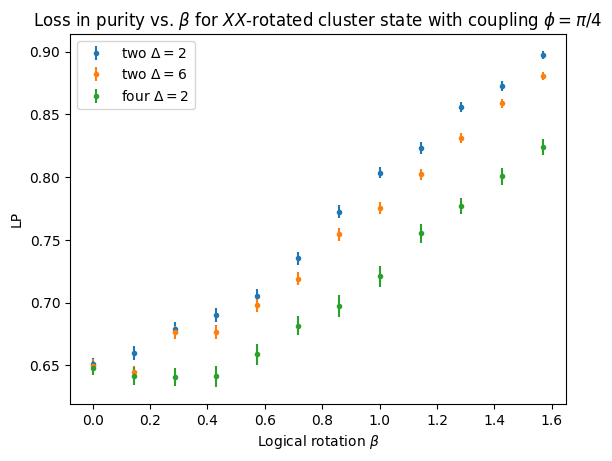

In [25]:
plt.errorbar(beta_ar, two_rot_close_purity_ar, yerr=two_rot_close_purity_err_ar, label=r"two $\Delta = 2$", ls="none", marker=".")
plt.errorbar(beta_ar, two_rot_far_purity_ar, yerr=two_rot_far_purity_err_ar, label=r"two $\Delta = 6$", ls="none", marker=".")
plt.errorbar(beta_ar, four_rot_purity_ar, yerr=four_rot_purity_err_ar, label=r"four $\Delta = 2$", ls="none", marker=".")
plt.ylabel("LP")
plt.xlabel(r"Logical rotation $\beta$")
plt.title(r"Loss in purity vs. $\beta$ for $XX$-rotated cluster state with coupling $\phi = \pi/4$")
plt.legend(loc="best")
plt.show()

In [70]:
#np.savez("processed_data/CI_purities_restricted.npz", beta_ar=beta_ar, two_rot_close_purity_ar=two_rot_close_purity_ar, two_rot_close_purity_err_ar=two_rot_close_purity_err_ar, two_rot_far_purity_ar=two_rot_far_purity_ar, two_rot_far_purity_err_ar=two_rot_far_purity_err_ar, four_rot_purity_ar=four_rot_purity_ar, four_rot_purity_err_ar=four_rot_purity_err_ar)

## Noisy Simulation

In [32]:
shots_num_sim = 4000000
beta_ar_sim = np.linspace(0, np.pi/2, 50)
qc_list_sim = generate_counterintuitive_circuits(beta_ar_sim, phi_ar)

In [206]:
shots_num_sim = 1000000
beta_ar_sim = np.linspace(0, np.pi/2, 12)
qc_list_sim = generate_counterintuitive_circuits(beta_ar_sim, phi_ar)

In [33]:
noise_model = NoiseModel()
p_gate = 0.0205

# Add depolarizing error to all 2-qubit gates
error_gate2 = depolarizing_error(p_gate, 2)
noise_model.add_all_qubit_quantum_error(error_gate2, ["cz"])
noise_model.add_all_qubit_quantum_error(error_gate2, ["cx"])

# Print noise model info
print(noise_model)

sim_noise = AerSimulator(noise_model=noise_model)

NoiseModel:
  Basis gates: ['cx', 'cz', 'id', 'rz', 'sx']
  Instructions with noise: ['cx', 'cz']
  All-qubits errors: ['cz', 'cx']


In [116]:
noise_model = NoiseModel()
p_gate = 0.015
t1 = 200e3 #290e3
t2 = 150e3 #225e3
t1s = t1 * np.ones(11)
t2s = t2 * np.ones(11)
time_readout = 835
time_ecr = 594


# Add depolarizing error to all 2-qubit gates
error_gate2 = depolarizing_error(p_gate, 2)
errors_thermal_gate2 = thermal_relaxation_error(t1, t2, time_ecr).expand(thermal_relaxation_error(t1, t2, time_ecr))
errors_thermal_readout = thermal_relaxation_error(t1, t2, time_readout)
noise_model.add_all_qubit_quantum_error(error_gate2, ["cz"])
noise_model.add_all_qubit_quantum_error(error_gate2, ["cx"])
noise_model.add_all_qubit_quantum_error(errors_thermal_gate2, ["cz"])
noise_model.add_all_qubit_quantum_error(errors_thermal_gate2, ["cx"])
noise_model.add_all_qubit_quantum_error(errors_thermal_readout, ["measure"])

# Print noise model info
print(noise_model)

sim_noise = AerSimulator(noise_model=noise_model)

NoiseModel:
  Basis gates: ['cx', 'cz', 'id', 'rz', 'sx']
  Instructions with noise: ['cx', 'measure', 'cz']
  All-qubits errors: ['cz', 'cx', 'measure']


In [34]:
job_sim = sim_noise.run(qc_list_sim, shots=shots_num_sim)
job_sim_result = job_sim.result()

In [35]:
counts_list_sim = []
for i in range(len(qc_list_sim)):
    counts_list_sim.append(job_sim_result.get_counts(i))

CI_ar_sim = post_process_results(counts_list_sim, beta_ar_sim, phi_ar)
tworot_purities_sim = CI_ar_sim[0*len(beta_ar_sim):1*len(beta_ar_sim)]
tworot_spaced_purities_sim = CI_ar_sim[1*len(beta_ar_sim):2*len(beta_ar_sim)]
fourrot_purities_sim = CI_ar_sim[2*len(beta_ar_sim):3*len(beta_ar_sim)]

In [ ]:
data = np.load("CI_purities_sim_optimal_p0205_4mshots.npz")
# beta_ar_sim = data["beta_ar"]
tworot_purities_sim = data["tworot_purities_sim"]
tworot_spaced_purities_sim = data["tworot_spaced_purities_sim"]
fourrot_purities_sim = data["fourrot_purities_sim"]


NpzFile 'CI_purities_sim_optimal_p0205_4mshots.npz' with keys: arr_0, arr_1


KeyError: 'tworot_purities_sim is not a file in the archive'

In [2]:
data = np.load("CI_purities_sep.npz")
beta_ar = data["beta_ar"]
two_rot_close_purity_ar = data["two_rot_close_purity_ar"]
two_rot_close_purity_err_ar = data["two_rot_close_purity_err_ar"]
two_rot_far_purity_ar = data["two_rot_far_purity_ar"]
two_rot_far_purity_err_ar = data["two_rot_far_purity_err_ar"]
four_rot_purity_ar = data["four_rot_purity_ar"]
four_rot_purity_err_ar = data["four_rot_purity_err_ar"]

In [39]:
np.save("2025_beta_ar_CI_exp.npy", beta_ar)
np.save("2025_twoclose_CI_exp.npy", two_rot_close_purity_ar)
np.save("2025_twofar_CI_exp.npy", two_rot_far_purity_ar)
np.save("2025_four_CI_exp.npy", four_rot_purity_ar)
np.save("2025_beta_ar_CI_sim02054m.npy", beta_ar_sim)
np.save("2025_twoclose_CI_sim02054m.npy", tworot_purities_sim)
np.save("2025_twofar_ar_CI_sim02054m.npy",tworot_spaced_purities_sim)
np.save("2025_four_ar_CI_sim02054m.npy", fourrot_purities_sim)

In [3]:
beta_ar_sim = np.load("2025_beta_ar_CI_sim02054m.npy")
tworot_purities_sim = np.load("2025_twoclose_CI_sim02054m.npy")
tworot_spaced_purities_sim = np.load("2025_twofar_ar_CI_sim02054m.npy")
fourrot_purities_sim = np.load("2025_four_ar_CI_sim02054m.npy")

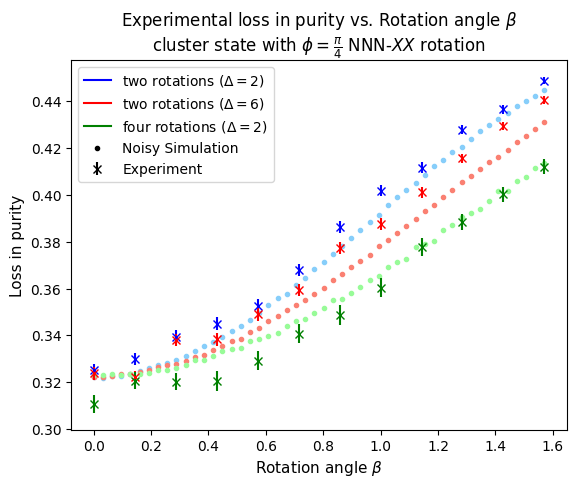

In [5]:
# all computations so far have used 1 - <X>^2 - <Y>^2 so divide by 2 to get LP
plt.plot(beta_ar_sim, tworot_purities_sim/2, ".", color = "lightskyblue")
plt.plot(beta_ar_sim, tworot_spaced_purities_sim/2, ".", color = "salmon")
plt.plot(beta_ar_sim, fourrot_purities_sim/2, ".", color = "palegreen")

plt.errorbar(beta_ar, two_rot_close_purity_ar/2, yerr=two_rot_close_purity_err_ar/2, fmt="x", color="blue")
plt.errorbar(beta_ar, two_rot_far_purity_ar/2, yerr=two_rot_far_purity_err_ar/2, fmt="x", color="red")
plt.errorbar(beta_ar, four_rot_purity_ar/2, yerr=four_rot_purity_err_ar/2, fmt="x", color="green")

plt.plot([], [], "b-", label=r"two rotations ($\Delta=2$)")
plt.plot([], [], "r-", label=r"two rotations ($\Delta=6$)")
plt.plot([], [], "g-", label=r"four rotations ($\Delta = 2$)")
# plt.plot([], [], "k-", label="Theory")
plt.plot([], [], "k.", label=r"Noisy Simulation")
plt.errorbar([], [], [], fmt="x", color="black", label="Experiment")

plt.title(r"Experimental loss in purity vs. Rotation angle $\beta$" + "\n" + r"cluster state with $\phi = \frac{\pi}{4}$ NNN-$XX$ rotation")
plt.xlabel(r"Rotation angle $\beta$", size=11)
plt.ylabel(r"Loss in purity", size=11)
plt.legend(loc="best")
plt.savefig("figures/dec9correction_CIregime.pdf")
plt.show()

In [237]:
np.savez("CI_purities_sep", beta_ar=beta_ar, two_rot_close_purity_ar=two_rot_close_purity_ar, two_rot_close_purity_err_ar=two_rot_close_purity_err_ar, two_rot_far_purity_ar=two_rot_far_purity_ar, two_rot_far_purity_err_ar=two_rot_far_purity_err_ar, four_rot_purity_ar=four_rot_purity_ar, four_rot_purity_err_ar=four_rot_purity_err_ar)

In [223]:
# np.savez("CI_purities_sim_optimal_p020_1mshots.npz", CI_ar_sim)
# CI_purities_p020 = CI_ar_sim

# np.savez("CI_purities_sim_optimal_p0205_1mshots.npz", CI_ar_sim)
# CI_purities_p0205 = CI_ar_sim

np.savez("CI_purities_sim_optimal_p021_1mshots.npz", CI_ar_sim)
CI_purities_p021 = CI_ar_sim

In [224]:
print(np.sum((CI_purities_p020-purity_ar_mean)**2))
print(np.sum((CI_purities_p0205-purity_ar_mean)**2))
print(np.sum((CI_purities_p021-purity_ar_mean)**2))

0.010662483167457116
0.0069267921400035576
0.007216664867960312


In [236]:
np.savez("CI_purities_sim_optimal_p0205_4mshots.npz", beta_ar_sim, CI_ar_sim)

In [238]:
data = np.load("CI_purities_sep.npz")